# 서울시 골목상권 폐업위험 조기경보 — 데이터 준비와 탐색

> **핵심 질문** — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

이 노트북은 **적재 → 결합 → 라벨 → 기초 탐색 → 기준선·가설 검토** 까지를 다룸.
예측 모델링(머신러닝)은 이 노트북의 산출물을 입력으로 하는 **다음 노트북**에서 수행함.

## 분석 단위와 기간

| 항목 | 값 |
|---|---|
| 분석 단위 | 상권 × 서비스업종 × 분기 |
| 업종 범위 | 요식업 10종 |
| 기간 | 2023Q1 ~ 2025Q4 (라벨 생성을 위해 2026Q1까지 적재) |
| 라벨 | `y(t) = 1 if 개업_점포_수(t+1) − 폐업_점포_수(t+1) < 0 else 0` |

## 데이터 출처

**서울시 우리마을가게 상권분석서비스** — 서울특별시 주관 / 서울신용보증재단 위탁운영
배포: 서울 열린데이터광장 (`data.seoul.go.kr`), 공공누리 1유형

원천은 추정매출 = 신한카드 결제액 ÷ 보정비율, 유동인구 = 서울시·KT 생활인구,
점포 = 국세청 사업자등록 기반임. 이 때문에 **"폐업"은 실제 폐점이 아니라 사업자등록 말소 시점**이며,
매출은 단일 카드사 기반 추정치임. 결론을 쓸 때 해석의 폭을 이 범위로 좁힘.

## 이 노트북에서 내린 판단

1. **점포 컬럼 대응** — 연도별 파일의 `유사_업종_점포_수` = 신 기준 `전체_점포_수`,
   `점포_수` = `일반_점포_수`. `전체 = 일반 + 프랜차이즈` 항등식으로 검증함.
2. **집객시설의 빈칸은 0으로 채움** — 시설이 없는 경우를 빈칸으로 저장하는 형식임(원본에 `0` 표기 없음).
   보유율이 지나치게 낮은 항목만 제외하고 **나머지는 모두 남겨** 다음 노트북의 기여도 검토에 넘김.
3. **인구는 총량 하나만** — 유동인구가 상주·직장을 이미 포함하므로 길단위인구만 씀.
   `직장인구_비중`은 넣어 재본 뒤 판별력이 없어(단변량 AUC 0.520) 제외함.
4. **2021~2022 제외** — 방역 조치가 개·폐업을 좌우한 구간.
5. **상권변화지표의 4분면 지표는 피처가 아니라 기준선** — 폐업 정보로 만들어져 라벨과 원천이 같음.
   같은 파일의 `폐업_영업_개월_평균`도 같은 이유로 제외함.
6. **`y=0`은 두 상태의 합** — 「변화 없음」과 「변화 있었으나 줄지 않음」을 분해해 진단하되
   **표본에서 버리지 않음**. 이유는 3-1에서 상세히 다룸.
7. **`운영_영업_개월_평균`은 피처로 씀** — 상권변화지표의 재료 중 폐업 정보가 아닌 쪽임.
   상권·분기마다 값이 달라 순위에 기여할 수 있음. 판별력은 6장에서 재 봄.
8. **전국 경제지표는 넣어 보고 판정함** — 한 분기 안에서 모든 상권이 같은 값이라
   순위를 바꾸지 못한다는 것을 6장에서 수치로 확인함. 말로만 빼지 않고 확인 기록을 남김.


---
# 1. 원본 적재와 스키마 통일

In [1]:
import os, sys, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import chi2_contingency, kruskal

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

for cand in ["C:/Windows/Fonts/malgun.ttf", "/System/Library/Fonts/AppleSDGothicNeo.ttc"]:
    if Path(cand).exists():
        fm.fontManager.addfont(cand)
        plt.rcParams["font.family"] = fm.FontProperties(fname=cand).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

RAW = Path(os.environ.get(
    "SANGKWON_RAW",
    Path.home() / "OneDrive" / "바탕 화면" / "AI 데이터 인텔리전스" / "종합 과제" / "데이터"))
PROC = Path("data/processed"); PROC.mkdir(parents=True, exist_ok=True)
FIG  = Path("figures");        FIG.mkdir(parents=True, exist_ok=True)
ENC = "cp949"

Q_FEATURE = [20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244,
             20251, 20252, 20253, 20254]
Q_ALL = Q_FEATURE + [20261]          # 20261은 20254의 라벨을 만들기 위해서만 보유함
MIN_STORES = 5                        # 표본 필터 기준
TARGET_TYPE = "골목상권"

FOOD = ["한식음식점", "중식음식점", "일식음식점", "양식음식점", "분식전문점",
        "패스트푸드점", "치킨전문점", "제과점", "커피-음료", "호프-간이주점"]

print("원본 폴더:", RAW, "| 존재:", RAW.exists())

원본 폴더: C:\Users\지선호\OneDrive\바탕 화면\AI 데이터 인텔리전스\종합 과제\데이터 | 존재: True


In [2]:
FILES = {
    "store_api": "서울시 상권분석서비스(점포-상권)_API.csv",
    "sales_api": "서울시 상권분석서비스(추정매출-상권)_API.csv",
    "area":      "서울시 상권분석서비스(영역-상권).csv",
    "flow":      "서울시 상권분석서비스(길단위인구-상권).csv",
    "facility":  "서울시 상권분석서비스(집객시설-상권).csv",
    "change_ix": "서울시 상권분석서비스(상권변화지표-상권).csv",
    "macro":     "경제지표(ECOS)_월별_원본.csv",
}
for k, v in FILES.items():
    ok = (RAW/v).exists() or (RAW/(v+".gz")).exists()
    print(f"  [{'OK' if ok else '없음':>3}] {k:11} {v}")

def path(name):
    """원본은 .csv 또는 .csv.gz 어느 쪽이어도 읽음(저장소 용량 제한 때문에 gz로 보관함)"""
    for p in (RAW / name, RAW / (name + ".gz")):
        if p.exists():
            return p
    raise FileNotFoundError(f"파일 없음: {RAW / name} (.gz 포함해 찾지 못함)")

def read(name, **kw):
    return pd.read_csv(path(name), encoding=ENC, low_memory=False, **kw)

  [ OK] store_api   서울시 상권분석서비스(점포-상권)_API.csv
  [ OK] sales_api   서울시 상권분석서비스(추정매출-상권)_API.csv
  [ OK] area        서울시 상권분석서비스(영역-상권).csv
  [ OK] flow        서울시 상권분석서비스(길단위인구-상권).csv
  [ OK] facility    서울시 상권분석서비스(집객시설-상권).csv
  [ OK] change_ix   서울시 상권분석서비스(상권변화지표-상권).csv
  [ OK] macro       경제지표(ECOS)_월별_원본.csv


## 1-1. 점포-상권

Open API 통합본은 21개 분기가 하나의 스키마로 들어 있어 연도별 파일을 이어 붙일 필요가 없음.

| 2023 · 2024 | 2025~ |
|---|---|
| `유사_업종_점포_수` | `전체_점포_수` |
| `점포_수` | `일반_점포_수` |

컬럼명은 의미가 분명한 신 기준(전체 / 일반)으로 통일함.

파일이 160만 행이므로 **20만 행씩 나누어 읽으면서** 기간 필터와 요식업 필터를 바로 적용함.
밀도의 분모가 되는 `상권_전체점포`는 요식업으로 거르기 **전** 100개 업종 전체의 합이어야 하므로,
같은 순회 안에서 따로 집계함.

In [3]:
def unify_store(df):
    ren = {}
    if "유사_업종_점포_수" in df.columns: ren["유사_업종_점포_수"] = "전체_점포_수"
    if "점포_수" in df.columns:          ren["점포_수"] = "일반_점포_수"
    return df.rename(columns=ren)

STORE_COLS = ["기준_년분기_코드", "상권_구분_코드_명", "상권_코드", "상권_코드_명",
              "서비스_업종_코드", "서비스_업종_코드_명",
              "전체_점포_수", "일반_점포_수", "프랜차이즈_점포_수",
              "개업_점포_수", "폐업_점포_수"]

food_parts, tot_parts, n_raw, ok_n, ok_d, quarters = [], [], 0, 0, 0, set()
for chunk in pd.read_csv(path(FILES["store_api"]), encoding=ENC,
                         low_memory=False, chunksize=200_000):
    chunk = unify_store(chunk)
    n_raw += len(chunk); quarters |= set(chunk["기준_년분기_코드"].unique())
    # 항등식 검증은 원본 전체에 대해 누적함
    d_ = (chunk["전체_점포_수"] - (chunk["일반_점포_수"] + chunk["프랜차이즈_점포_수"])).abs()
    ok_n += int((d_ < 1e-6).sum()); ok_d += len(d_)
    chunk = chunk.loc[chunk["기준_년분기_코드"].isin(Q_ALL), STORE_COLS]
    tot_parts.append(chunk.groupby(["기준_년분기_코드", "상권_코드"], sort=False)["전체_점포_수"].sum())
    food_parts.append(chunk[chunk["서비스_업종_코드_명"].isin(FOOD)])
    del chunk, d_

store = pd.concat(food_parts, ignore_index=True)
tot_all = (pd.concat(tot_parts).groupby(level=[0, 1]).sum()
           .rename("상권_전체점포").reset_index())
del food_parts, tot_parts; gc.collect()

print(f"원본 {n_raw:,}행 · 분기 {len(quarters)}개 ({min(quarters)}~{max(quarters)})")
print(f"전체 = 일반 + 프랜차이즈 성립률 {ok_n/ok_d:.4%}")
assert ok_n/ok_d > 0.999, "컬럼 대응 오류 — 유사_업종_점포_수 ↔ 전체_점포_수 매칭을 확인할 것"
print(f"→ 대응 확인됨 · 기간·요식업 필터 후 {len(store):,}행 · 상권집계 {len(tot_all):,}행")

원본 1,604,844행 · 분기 21개 (20211~20261)
전체 = 일반 + 프랜차이즈 성립률 100.0000%
→ 대응 확인됨 · 기간·요식업 필터 후 160,352행 · 상권집계 21,450행


## 1-2. 나머지 테이블

`영역-상권`은 분기 개념이 없는 마스터임. 매출은 카드 결제가 잡히는 칸에만 존재해 점포보다 성김.

In [4]:
SALES_COLS = ["기준_년분기_코드", "상권_코드", "서비스_업종_코드", "당월_매출_금액", "당월_매출_건수"]
sales = read(FILES["sales_api"], usecols=SALES_COLS)
sales = sales[sales["기준_년분기_코드"].isin(Q_ALL)].copy()

area     = read(FILES["area"])
flow     = read(FILES["flow"], usecols=["기준_년분기_코드", "상권_코드", "총_유동인구_수"])
facility = read(FILES["facility"])
chg      = read(FILES["change_ix"])

for nm, df in [("점포(요식업)", store), ("매출", sales), ("영역", area), ("길단위인구", flow),
               ("집객시설", facility), ("상권변화지표", chg)]:
    q = df["기준_년분기_코드"].nunique() if "기준_년분기_코드" in df else 0
    print(f"  {nm:12} {len(df):>9,}행 · 상권 {df['상권_코드'].nunique():>5}개 · 분기 {q}")
_ = gc.collect()

  점포(요식업)        160,352행 · 상권  1636개 · 분기 13
  매출             282,345행 · 상권  1587개 · 분기 13
  영역               1,650행 · 상권  1650개 · 분기 0
  길단위인구           34,633행 · 상권  1650개 · 분기 21
  집객시설            33,138행 · 상권  1578개 · 분기 21
  상권변화지표          34,650행 · 상권  1650개 · 분기 21


### 집객시설의 빈칸은 0으로 채움

집객시설 파일은 **시설이 없는 경우를 빈칸으로 저장**하는 방식임.
원본 전체에 `0` 표기가 한 건도 없다는 점으로 이를 확인함.
따라서 `지하철_역_수`가 비어 있는 것은 해당 상권에 지하철역이 없다는 뜻이므로 `fillna(0)` 으로 채움.

**어떤 항목을 남길 것인가.** 보유율(값이 1 이상인 상권 비율)이 1% 미만인 항목은
거의 모든 칸이 같은 값이라 학습에 기여할 정보가 없으므로 제외함.
그 외에는 **모두 남김.** 시설 수는 상권 규모와 함께 커지는 경향이 있어 규모의 대리변수가 되기 쉬운데,
그 판단은 눈으로 미리 하지 않고 **다음 노트북에서 기여도와 규모 상관을 함께 본 뒤** 내림.
여기서는 판단 근거가 되는 두 값을 미리 계산해 둠.

In [5]:
fac_cols = [c for c in facility.columns if c.endswith("_수")]
zero_written = int((facility[fac_cols] == 0).sum().sum())
before = facility[fac_cols].isna().mean().mean()
facility[fac_cols] = facility[fac_cols].fillna(0)
facility["역세권"] = (facility["지하철_역_수"] > 0).astype(int)
print(f"원본에 0으로 적힌 칸 {zero_written}개 → 빈칸은 결측이 아니라 '없음'을 뜻함")
print(f"집객시설 결측률 {before:.1%} → 0.0% · 역세권 상권 비율 {facility['역세권'].mean():.1%}\n")

DETAIL = [c for c in fac_cols if c != "집객시설_수"]
size_ref = facility["집객시설_수"]                     # 상권 활성도의 대리로 삼아 상관을 봄
diag = pd.DataFrame({
    "보유율":   facility[DETAIL].gt(0).mean(),
    "평균개수": facility[DETAIL].mean(),
    "규모상관": [facility[c].corr(size_ref, method="spearman")
                if facility[c].nunique() > 1 else np.nan for c in DETAIL],
}).sort_values("보유율", ascending=False)
diag["판정"] = np.where(diag["보유율"] < 0.01, "제외(정보 없음)", "유지")
display(diag.round(3))

FAC_KEEP = diag.index[diag["판정"] == "유지"].tolist()
print(f"유지 {len(FAC_KEEP)}개: {FAC_KEEP}")
print(f"제외 {len(DETAIL)-len(FAC_KEEP)}개: {[c for c in DETAIL if c not in FAC_KEEP]}")
print("\n※ 규모상관이 높은 항목도 이 단계에서는 남김. 기여도를 본 뒤 다음 노트북에서 정리함.")

원본에 0으로 적힌 칸 0개 → 빈칸은 결측이 아니라 '없음'을 뜻함
집객시설 결측률 81.2% → 0.0% · 역세권 상권 비율 12.4%



,보유율,평균개수,규모상관,판정
버스_정거장_수,0.805,3.896,0.756,유지
약국_수,0.639,2.359,0.783,유지
관공서_수,0.399,0.695,0.487,유지
은행_수,0.309,1.015,0.610,유지
지하철_역_수,0.124,0.176,0.454,유지
유치원_수,0.096,0.112,0.142,유지
숙박_시설_수,0.092,0.213,0.190,유지
일반_병원_수,0.084,0.107,0.309,유지
슈퍼마켓_수,0.067,0.102,0.042,유지
극장_수,0.053,0.072,0.273,유지


유지 12개: ['버스_정거장_수', '약국_수', '관공서_수', '은행_수', '지하철_역_수', '유치원_수', '숙박_시설_수', '일반_병원_수', '슈퍼마켓_수', '극장_수', '대학교_수', '종합병원_수']
제외 7개: ['초등학교_수', '중학교_수', '고등학교_수', '백화점_수', '공항_수', '철도_역_수', '버스_터미널_수']

※ 규모상관이 높은 항목도 이 단계에서는 남김. 기여도를 본 뒤 다음 노트북에서 정리함.


### 상권변화지표 — 지표는 기준선, 운영개월은 피처

서울시가 이미 공식으로 쓰는 4분면 진단임(`운영_영업_개월_평균`·`폐업_영업_개월_평균`을 서울 평균과 비교).

**4분면 지표 자체는 피처로 쓰지 않음.** 폐업 정보로 만들어져 우리 라벨과 원천이 같기 때문임.
모델에 넣으면 "폐업이 많아서 폐업한다"는 순환 설명이 되어 «무엇이 위험을 만드는가»가 무의미해짐.
대신 **모델이 넘어야 할 기준선**으로 5장에서 사용함.

**다만 재료 중 하나는 쓸 수 있음.** 지표를 만드는 두 값의 성격이 다름.

| 값 | 무엇으로 만들어지는가 | 판정 |
|---|---|---|
| `폐업_영업_개월_평균` | **문 닫은** 점포들의 영업 기간 | 라벨과 원천 공유 → 쓰지 않음 |
| `운영_영업_개월_평균` | **영업 중인** 점포들의 영업 기간 | 폐업 정보가 아님 → **피처로 씀** |

`운영_영업_개월_평균`은 「이 상권의 가게들이 얼마나 오래 버텄는가」이며,
값이 낮으면 최근에 새로 들어온 가게가 많다는 뜻임. 6-1에서 판별력을 재 봄.


In [6]:
IX_COLS = ["기준_년분기_코드", "상권_코드", "상권_변화_지표", "상권_변화_지표_명",
           "운영_영업_개월_평균", "폐업_영업_개월_평균",
           "서울_운영_영업_개월_평균", "서울_폐업_영업_개월_평균"]
chg = chg[IX_COLS].copy()
chg["기준선_위험"] = (chg["상권_변화_지표"] == "HL").astype(int)   # HL = 상권축소
chg["운영개월_서울대비"] = chg["운영_영업_개월_평균"] / chg["서울_운영_영업_개월_평균"]
print(chg.groupby(["상권_변화_지표", "상권_변화_지표_명"]).size().rename("건수").to_string())
print(f"\n기준선(HL) 양성률 {chg['기준선_위험'].mean():.1%}")

print("\n분기 안에서 변하는가 — 이 조건을 통과해야 상권 간 순위에 기여할 수 있음")
for c_ in ["운영_영업_개월_평균", "폐업_영업_개월_평균", "서울_운영_영업_개월_평균"]:
    n = chg.groupby("기준_년분기_코드")[c_].nunique()
    print(f"  {c_:22} 분기별 고유값 {n.min()}~{n.max()}개")
print("→ 서울 평균은 분기마다 값이 하나뿐이므로 그 자체로는 순위를 바꾸지 못함.")
print("  상권값 ÷ 서울평균 비율만 분기 간 수준 이동을 지우는 용도로 씀.")

상권_변화_지표  상권_변화_지표_명
HH        정체            11356
HL        상권축소           7597
LH        상권확장           5062
LL        다이나믹          10635

기준선(HL) 양성률 21.9%

분기 안에서 변하는가 — 이 조건을 통과해야 상권 간 순위에 기여할 수 있음
  운영_영업_개월_평균            분기별 고유값 144~156개
  폐업_영업_개월_평균            분기별 고유값 68~78개
  서울_운영_영업_개월_평균         분기별 고유값 1~1개
→ 서울 평균은 분기마다 값이 하나뿐이므로 그 자체로는 순위를 바꾸지 못함.
  상권값 ÷ 서울평균 비율만 분기 간 수준 이동을 지우는 용도로 씀.


## 1-3. 후보 변수 — 전국 경제지표

**결론을 미리 말하면 이 두 변수는 상권 간 순위를 바꾸지 못함.** 그래도 넣어 두는 이유는
«왜 못 하는가»를 6-1에서 수치로 보이기 위함임. 빼고 말로만 설명하면 확인할 방법이 없음.

| 지표 | 뜻하는 것 | 출처 |
|---|---|---|
| 음식서비스 소비자물가지수 | 외식 가격·원가 압박 | 통계청 소비자물가조사 (2020=100) |
| 외식비 지출전망CSI | 가계가 앞으로 외식을 늘릴지 줄일지 | 한국은행 소비자동향조사 (100 미만 = 줄이겠다는 응답이 많음) |

둘 다 **전국 단위 월별 지표**이므로 같은 분기의 모든 상권에 같은 값이 붙음.
월 → 분기 변환은 둘 다 수준값이므로 분기 평균을 취함.


In [7]:
macro_raw = read(FILES["macro"])
macro_raw = macro_raw[macro_raw["세부명"].isna() | (macro_raw["세부명"] == "전체")]
macro_raw["기준_년분기_코드"] = (macro_raw["연월"] // 100) * 10 + (macro_raw["연월"] % 100 - 1) // 3 + 1
macro = (macro_raw.pivot_table(index="기준_년분기_코드", columns="지표", values="값", aggfunc="mean")
         .rename(columns={"음식서비스_소비자물가지수": "외식물가지수",
                          "외식비_지출전망CSI": "외식지출전망"})
         .reset_index())
macro = macro[macro["기준_년분기_코드"].isin(Q_ALL)].reset_index(drop=True)
display(macro.round(2))
print("→ 분기마다 값이 하나씩. 같은 분기 안의 5,500여 칸이 모두 같은 값을 받게 됨")

지표,기준_년분기_코드,외식지출전망,외식물가지수
0,20231,90.33,115.42
1,20232,95.67,117.32
2,20233,97.33,118.04
3,20234,93.67,118.73
4,20241,95.33,119.82
5,20242,95.00,120.76
6,20243,95.67,121.26
7,20244,93.00,122.18
8,20251,90.33,123.37
9,20252,94.33,124.57


→ 분기마다 값이 하나씩. 같은 분기 안의 5,500여 칸이 모두 같은 값을 받게 됨


## 1-4. 기간 필터

제외 근거는 표지 「이 노트북에서 내린 판단」 4번에 있음. 여기서는 필터 전후 행 수만 남김.


In [8]:
def clip_q(df, name):
    if "기준_년분기_코드" not in df.columns: return df
    n0 = len(df); out = df[df["기준_년분기_코드"].isin(Q_ALL)].copy()
    print(f"  {name:12} {n0:>9,} → {len(out):>9,}")
    return out

print("기간 필터 2023Q1~2026Q1")
flow     = clip_q(flow, "길단위인구");   facility = clip_q(facility, "집객시설")
chg      = clip_q(chg, "상권변화지표")

# 키 유일성 — 결합 전에 반드시 확인함
for nm, df, k in [("점포", store, ["기준_년분기_코드","상권_코드","서비스_업종_코드"]),
                  ("매출", sales, ["기준_년분기_코드","상권_코드","서비스_업종_코드"]),
                  ("영역", area, ["상권_코드"]),
                  ("길단위인구", flow, ["기준_년분기_코드","상권_코드"]),
                  ("집객시설", facility, ["기준_년분기_코드","상권_코드"]),
                  ("상권변화지표", chg, ["기준_년분기_코드","상권_코드"]),
                  ("경제지표", macro, ["기준_년분기_코드"])]:
    assert df.duplicated(k).sum() == 0, f"{nm} 키 중복"
print("모든 테이블의 키가 유일함")

기간 필터 2023Q1~2026Q1
  길단위인구           34,633 →    21,434
  집객시설            33,138 →    20,514
  상권변화지표          34,650 →    21,450


모든 테이블의 키가 유일함


---
# 2. 결합 — 요식업 패널 만들기

| 대상 | 결합 키 |
|---|---|
| 영역-상권 | `상권_코드` |
| 길단위인구 · 집객시설 · 상권변화지표 | `상권_코드` + `기준_년분기_코드` |
| 추정매출 | `상권_코드` + `기준_년분기_코드` + `서비스_업종_코드` |
| 경제지표 | `기준_년분기_코드` |

좌결합 후 **행 수가 늘면 키 중복**이므로 즉시 중단함. 이 단계의 최대 위험임.

In [9]:
def check(before, after, tag):
    assert after == before, f"[{tag}] 행 증식 {before:,} → {after:,}"
    print(f"  [{tag:12}] {after:,} 유지")

df = store
n = len(df)
print(f"요식업 패널 {n:,}행에 부속 정보를 붙임")
df = df.merge(area[["상권_코드", "상권_구분_코드_명", "자치구_코드_명", "행정동_코드", "행정동_코드_명",
                    "영역_면적", "엑스좌표_값", "와이좌표_값"]]
              .rename(columns={"상권_구분_코드_명": "상권유형", "자치구_코드_명": "자치구",
                               "행정동_코드_명": "행정동"}),
              on="상권_코드", how="left");                                check(n, len(df), "영역")
df = df.merge(flow, on=["기준_년분기_코드", "상권_코드"], how="left");      check(n, len(df), "길단위인구")
df = df.merge(facility[["기준_년분기_코드", "상권_코드", "역세권"] + FAC_KEEP],
              on=["기준_년분기_코드", "상권_코드"], how="left");            check(n, len(df), "집객시설")
df = df.merge(chg[["기준_년분기_코드", "상권_코드", "상권_변화_지표", "기준선_위험",
                   "운영_영업_개월_평균", "운영개월_서울대비"]],
              on=["기준_년분기_코드", "상권_코드"], how="left");            check(n, len(df), "상권변화지표")
df = df.merge(sales, on=["기준_년분기_코드", "상권_코드", "서비스_업종_코드"],
              how="left");                                              check(n, len(df), "추정매출")
df = df.merge(tot_all, on=["기준_년분기_코드", "상권_코드"], how="left");   check(n, len(df), "상권집계")
df = df.merge(macro, on="기준_년분기_코드", how="left");                   check(n, len(df), "경제지표")

# 요식업 10종 합계 — 표본 필터 이전의 전수로 계산해야 밀도가 왜곡되지 않음
food_tot = (df.groupby(["기준_년분기_코드", "상권_코드"], sort=False)["전체_점포_수"]
            .sum().rename("요식업_전체점포").reset_index())
df = df.merge(food_tot, on=["기준_년분기_코드", "상권_코드"], how="left"); check(n, len(df), "요식업집계")

del store, sales, flow; gc.collect()
print(f"\n결합 완료 {df.shape}")

요식업 패널 160,352행에 부속 정보를 붙임
  [영역          ] 160,352 유지
  [길단위인구       ] 160,352 유지
  [집객시설        ] 160,352 유지
  [상권변화지표      ] 160,352 유지


  [추정매출        ] 160,352 유지
  [상권집계        ] 160,352 유지
  [경제지표        ] 160,352 유지
  [요식업집계       ] 160,352 유지

결합 완료 (160352, 42)


## 2-1. 결측률

결측률이 높은 변수는 공변량에서 빼야 함. 표본이 통째로 날아가기 때문임.

In [10]:
cols = ["엑스좌표_값", "영역_면적", "총_유동인구_수", "역세권",
        "상권_변화_지표", "당월_매출_금액", "상권_전체점포",
        "운영_영업_개월_평균", "운영개월_서울대비", "외식물가지수", "외식지출전망"]
miss = pd.DataFrame({"컬럼": cols, "결측률": [df[c].isna().mean() for c in cols]})
miss["판정"] = pd.cut(miss["결측률"], [-1, .05, .3, 1], labels=["OK", "주의", "공변량 제외 권장"])
miss["결측률"] = miss["결측률"].map("{:.1%}".format)
display(miss)
print("※ 매출 결측이 큰 이유는 결합 실수가 아니라, 카드 매출이 잡히지 않는 영세 칸에는 원본에 행이 없기 때문임.")
df.to_pickle(PROC / "02_merged.pkl")
print(f"[저장] 02_merged.pkl {df.shape}")

,컬럼,결측률,판정
0,엑스좌표_값,0.0%,OK
1,영역_면적,0.0%,OK
2,총_유동인구_수,0.0%,OK
3,역세권,2.3%,OK
4,상권_변화_지표,0.0%,OK
5,당월_매출_금액,45.4%,공변량 제외 권장
6,상권_전체점포,0.0%,OK
7,운영_영업_개월_평균,0.0%,OK
8,운영개월_서울대비,0.0%,OK
9,외식물가지수,0.0%,OK


※ 매출 결측이 큰 이유는 결합 실수가 아니라, 카드 매출이 잡히지 않는 영세 칸에는 원본에 행이 없기 때문임.


[저장] 02_merged.pkl (160352, 42)


---
# 3. 라벨 정의와 표본 설계

```
순증감(t) = 개업_점포_수(t) − 폐업_점포_수(t)
y(t)      = 1 if 순증감(t+1) < 0 else 0
```

두 가지를 지킴.
- `shift(-1)`은 반드시 **(상권, 업종) 그룹 내에서 분기 오름차순 정렬 후** 수행함
- 분기가 연속하지 않으면 라벨을 만들지 않음 (`20244 → 20251` 은 연속으로 처리함)

**표본 필터** — 점포 5개 미만 칸은 개·폐업이 거의 없어 라벨이 노이즈에 가까움.

In [11]:
def quarter_index(code):
    """20244 → 8099, 20251 → 8100. 연도 경계에서도 diff가 1이 되도록 함"""
    return (code // 10) * 4 + (code % 10 - 1)

df = pd.read_pickle(PROC / "02_merged.pkl")
df["분기idx"]    = quarter_index(df["기준_년분기_코드"])
df["순증감"]     = df["개업_점포_수"] - df["폐업_점포_수"]
df["순감소_현재"] = (df["순증감"] < 0).astype(int)
df["사건_현재"]   = ((df["개업_점포_수"] + df["폐업_점포_수"]) >= 1).astype(int)

df = df.sort_values(["상권_코드", "서비스_업종_코드", "분기idx"]).reset_index(drop=True)
g = df.groupby(["상권_코드", "서비스_업종_코드"], sort=False)
for src, dst in [("개업_점포_수", "다음_개업"), ("폐업_점포_수", "다음_폐업"),
                 ("분기idx", "다음분기idx")]:
    df[dst] = g[src].shift(-1)
연속 = (df["다음분기idx"] - df["분기idx"]) == 1
df.loc[~연속, ["다음_개업", "다음_폐업"]] = np.nan
has = df["다음_폐업"].notna()

df["y"] = np.nan
df.loc[has, "y"] = (df.loc[has, "다음_폐업"] > df.loc[has, "다음_개업"]).astype(int)
df["사건_다음"] = np.nan
df.loc[has, "사건_다음"] = ((df.loc[has, "다음_개업"] + df.loc[has, "다음_폐업"]) >= 1).astype(int)

print(f"라벨 생성 가능 {int(has.sum()):,} / {len(df):,}")
print(f"점포 {MIN_STORES}개 미만 {(df['전체_점포_수'] < MIN_STORES).mean():.1%}")

라벨 생성 가능 147,138 / 160,352
점포 5개 미만 54.5%


In [12]:
필터단계 = [("원본", df)]
d = df[df["y"].notna()].copy();                  필터단계.append(("라벨 존재", d))
d = d[d["전체_점포_수"] >= MIN_STORES];            필터단계.append((f"점포 {MIN_STORES}개 이상", d))
d = d[d["총_유동인구_수"].notna()];                필터단계.append(("유동인구 존재", d))
d = d[d["영역_면적"] > 0];                        필터단계.append(("면적 유효", d))

prev = None
for nm, s in 필터단계:
    print(f"  {nm:16} {len(s):>8,}" + ("" if prev is None else f"  (-{prev-len(s):,})")); prev = len(s)
d["y"] = d["y"].astype(int); d["사건_다음"] = d["사건_다음"].astype(int)
print(f"\n최종 표본 {len(d):,} · 양성률 {d['y'].mean():.1%}")
display(d.groupby("기준_년분기_코드")["y"].agg(칸수="size", 순감소율="mean").round(3))
del df; _ = gc.collect()

  원본                160,352
  라벨 존재             147,138  (-13,214)
  점포 5개 이상           67,495  (-79,643)
  유동인구 존재            67,475  (-20)
  면적 유효              67,475  (-0)

최종 표본 67,475 · 양성률 25.5%


,칸수,순감소율
기준_년분기_코드,,
20231,5706,0.229
20232,5731,0.261
20233,5701,0.223
20234,5730,0.236
20241,5706,0.254
20242,5678,0.276
20243,5622,0.262
20244,5586,0.284
20251,5534,0.261


## 3-1. `y=0` 에 무엇이 섞여 있는가

라벨은 «다음 분기에 순감소인가»만 묻기 때문에, `y=0`은 **성격이 다른 두 상태의 합**임.

| 다음 분기 상태 | 조건 | 의미 |
|---|---|---|
| **변화 없음** | 개업 = 0 **그리고** 폐업 = 0 | 문을 연 곳도, 닫은 곳도 없음 |
| **변화 있었으나 줄지 않음** | 위와 아래 어디에도 해당하지 않는 나머지 | 개·폐업은 있었으나 점포가 줄지는 않음 |
| 순감소 (`y=1`) | 폐업 > 개업 | 점포가 순수하게 빠져나감 |

«변화 있었으나 줄지 않음»은 개업 3 · 폐업 2 처럼 **오히려 늘어난 경우**까지 포함함.
`개업 − 폐업 = 0`(예: 개업 100 · 폐업 100)만이 아니라 `개업 − 폐업 > 0` 도 여기에 들어감.
`y=1`의 조건이 «폐업 > 개업» 이므로 그 나머지 전부가 이 칸이 되기 때문임.

### 상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높음

**이것이 이 라벨의 가장 큰 약점임.** 점포가 6개뿐인 골목 칸에서 한 분기 동안 아무 일도
일어나지 않는 것은 그 상권이 **안전해서가 아니라 작아서**임. 개·폐업은 점포 수에 비례해
일어나는 사건이므로, 표본이 작으면 사건 자체가 관측되지 않을 확률이 높아짐.

```
점포 6개 칸    한 분기에 개·폐업이 한 건도 없을 수 있음   →  변화 없음  →  y = 0
점포 300개 칸  한 분기에 반드시 몇 건은 일어남           →  대개 순감소 아니면 증가
```

그 결과 «변화 없음» 칸이 `y=0`에 대량으로 쌓이고, 모형은 «위험하지 않은 조건»이 아니라
**«사건이 잘 안 일어나는 조건 = 규모가 작음»** 을 학습하게 됨.
아래 규모 구간별 표에서 규모가 커질수록 «변화 없음» 비율이 떨어지고 순감소율이 올라가는 것이
그 통로를 그대로 보여 줌.

### 그러면 사건이 있었던 칸만 쓰면 되지 않는가

**쓸 수 없음.** 개업 + 폐업 ≥ 1 인 칸만 고르려면 **다음 분기의 개업·폐업 건수를 먼저 알아야** 하는데,
그 값이 바로 우리가 맞히려는 라벨임. 라벨을 봐야 표본을 만들 수 있다는 순환에 빠짐.

실제 운영에서도 성립하지 않음. 조기경보는 «다음 분기에 사건이 있을 칸» 이 아니라
**지금 존재하는 모든 상권 × 업종에 점수를 매겨야** 함. 변화 없음 칸을 미리 걷어낸 표본에서 만든
모형은 그 상황에 쓸 수 없고, 위험 확률도 실제보다 높게 나옴.

### 그래서 이렇게 함

1. 변화 없음 칸을 **버리지 않음.** 표본은 그대로 둠.
2. 대신 세 상태의 비율과, **규모에 따라 «변화 없음»이 얼마나 달라지는지** 를 측정해 남김.
3. 이 구조를 모형으로 다루는 방법 — `P(사건) × P(순감소 | 사건)` 로 나누어 푸는 2단계 모형 — 은
   다음 노트북에서 단일 모형과 **같은 검증 데이터로** 비교해 강건성 검증으로 보고함.

아래 표가 2번의 근거임.


In [13]:
S_NONE, S_FLAT, S_DROP = "변화 없음", "변화 있었으나 줄지 않음", "순감소"

상태 = pd.Series(S_FLAT, index=d.index)
상태[(d["다음_개업"] + d["다음_폐업"]) == 0] = S_NONE
상태[d["y"] == 1] = S_DROP
d["다음상태"] = 상태

t = (상태.value_counts().rename_axis("다음 분기 상태").to_frame("건수")
     .reindex([S_NONE, S_FLAT, S_DROP]))
t["비율"] = (t["건수"] / t["건수"].sum()).round(3)
display(t)
print(f"y=0 {int((d['y']==0).sum()):,}건 가운데 «{S_NONE}»이 "
      f"{(상태[d['y']==0]==S_NONE).mean():.1%} — 절반을 넘음\n")

d["규모구간"] = pd.qcut(np.log(d["전체_점포_수"]), 5, labels=False, duplicates="drop")
size_tab = (d.assign(변화없음=(상태 == S_NONE).astype(int))
            .groupby("규모구간")
            .agg(칸수=("y", "size"), 평균점포=("전체_점포_수", "mean"),
                 변화없음비율=("변화없음", "mean"), 순감소율=("y", "mean")))
size_tab.index = [f"Q{i+1}" for i in size_tab.index]
display(size_tab.round(3))

lo, hi = size_tab.iloc[0], size_tab.iloc[-1]
print(f"→ 상권 규모가 작은 곳에서 «{S_NONE}»의 빈도가 높음: "
      f"평균 점포 {lo['평균점포']:.1f}개 구간 {lo['변화없음비율']:.1%} "
      f"→ {hi['평균점포']:.1f}개 구간 {hi['변화없음비율']:.1%}")
print(f"   같은 방향으로 순감소율은 {lo['순감소율']:.1%} → {hi['순감소율']:.1%} 로 올라감.")
print("   즉 라벨이 규모에 끌려가는 통로가 «변화 없음»임. 5-2에서 규모를 고정해 이 영향을 걷어냄.")


,건수,비율
다음 분기 상태,,
변화 없음,29633,0.439
변화 있었으나 줄지 않음,20652,0.306
순감소,17190,0.255


y=0 50,285건 가운데 «변화 없음»이 58.9% — 절반을 넘음



,칸수,평균점포,변화없음비율,순감소율
Q1,15520,5.436,0.693,0.151
Q2,14018,7.856,0.599,0.193
Q3,12139,11.735,0.465,0.243
Q4,12718,19.558,0.298,0.308
Q5,13080,65.466,0.079,0.403


→ 상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높음: 평균 점포 5.4개 구간 69.3% → 65.5개 구간 7.9%
   같은 방향으로 순감소율은 15.1% → 40.3% 로 올라감.
   즉 라벨이 규모에 끌려가는 통로가 «변화 없음»임. 5-2에서 규모를 고정해 이 영향을 걷어냄.


## 3-2. 밀도와 비중 — 서로 다른 세 가지

«점포가 빽빽하다» 는 말이 여러 갈래로 갈림. 셋은 **세는 대상과 분모가 모두 달라** 전혀 다른 값이므로
이름을 나눠 둠.

먼저 헷갈리기 쉬운 이름 하나를 정리함. **`전체_점포_수`는 「상권 전체 점포」가 아님.**
「그 행 업종의 일반 + 프랜차이즈 합계」임(`전체 = 일반 + 프랜차이즈` 항등식으로 1장에서 검증함).
상권 전체는 `상권_전체점포`(100개 업종 합)이고, 요식업 10종 합은 `요식업_전체점포`임.

| 변수 | 세는 대상 | 분모 | 읽는 법 |
|---|---|---|---|
| `업종점포비중` | 그 행 업종 | 상권 전체 100업종 점포 | 이 상권이 얼마나 이 업종에 쏠려 있는가 (0~1) |
| `해당업종_점포밀도` | **그 행 업종** | 영역면적 (1만㎡) | 1만㎡ 안에 **이 업종** 점포가 몇 개인가 |
| `요식업_점포밀도` | **요식업 10종 합** | 영역면적 (1만㎡) | 1만㎡ 안에 **요식업 전체** 점포가 몇 개인가 (경쟁 강도) |

예를 들어 연남동(홍대) 96,104㎡ 상권의 한식음식점 행이라면 —

```
해당업종_점포밀도   한식음식점 18개  ÷ 9.61만㎡ =  1.9
요식업_점포밀도    요식업 10종 144개 ÷ 9.61만㎡ = 15.0
업종점포비중      18 ÷ 상권 전체 318개 = 0.057
```

**`영역_면적`의 정의는 원본에 없음.** 컬럼 설명이 제공되지 않아 확인하지 못했고,
아래 두 가지로 보아 **상업 전용 면적이 아니라 상권 경계 폴리곤 전체 면적**으로 해석함.

```
점포 1개당 면적   중앙값 420㎡ · 95분위 1,106㎡     (상업 전용이면 50~200㎡ 정도여야 함)
최대 상권 면적    2,462,734㎡ = 2.46km²
```

따라서 이 값은 **공간상의 점포 집적도**이지 상업공간의 포화도가 아님. 해석을 그 범위로 제한함.

`전체_점포_수`는 밀도와 면적의 곱으로 다시 만들어지므로, 규모를 하나의 큰 변수로 넣는 대신
**밀도 · 면적 · 비중** 세 축으로 나누어 담음. 어느 축이 위험을 만드는지 구분해 보기 위함임.


In [14]:
면적_만제곱m = d["영역_면적"] / 10000

d["업종점포비중"]    = d["전체_점포_수"] / d["상권_전체점포"]
d["해당업종_점포밀도"]   = d["전체_점포_수"] / 면적_만제곱m
d["요식업_점포밀도"] = d["요식업_전체점포"] / 면적_만제곱m
d["프랜차이즈비율"]  = d["프랜차이즈_점포_수"] / d["전체_점포_수"]
d["점포당매출"]      = d["당월_매출_금액"] / d["전체_점포_수"]
d["매출결측"]        = d["당월_매출_금액"].isna().astype(int)

d["log_점포수"]      = np.log(d["전체_점포_수"])
d["log_유동인구"]    = np.log1p(d["총_유동인구_수"])
d["log_면적"]        = np.log(d["영역_면적"])
d["log_해당업종밀도"]    = np.log1p(d["해당업종_점포밀도"])
d["log_요식업밀도"]  = np.log1p(d["요식업_점포밀도"])
d["log_점포당매출"]  = np.log1p(d["점포당매출"])
for c in FAC_KEEP:
    d["밀도_" + c.replace("_수", "")] = d[c] / 면적_만제곱m

VIEW = ["업종점포비중", "해당업종_점포밀도", "요식업_점포밀도", "log_점포수", "log_면적",
        "log_유동인구", "log_점포당매출", "프랜차이즈비율"]
display(d[VIEW].describe().loc[["mean", "std", "min", "50%", "max"]].round(3))
print(f"매출 결측 {d['매출결측'].mean():.1%} — 버리지 않고 결측 표시 변수를 함께 둠")

d.to_pickle(PROC / "03_panel.pkl")
print(f"[저장] 03_panel.pkl {d.shape}")

,업종점포비중,해당업종_점포밀도,요식업_점포밀도,log_점포수,log_면적,log_유동인구,log_점포당매출,프랜차이즈비율
mean,0.054,1.942,11.827,2.584,11.634,13.657,16.997,0.212
std,0.052,2.899,9.922,0.849,0.842,1.016,1.208,0.214
min,0.001,0.071,0.268,1.609,7.525,2.197,5.751,0.000
50%,0.036,1.070,9.628,2.398,11.704,13.808,17.188,0.158
max,0.578,55.542,170.604,6.522,14.717,15.969,21.204,1.000


매출 결측 7.1% — 버리지 않고 결측 표시 변수를 함께 둠


[저장] 03_panel.pkl (67475, 77)


---
# 4. 기초 탐색

데이터가 분석 가능한 상태인지 확인함.

In [15]:
print(f"표본 {d.shape} · 양성률 {d['y'].mean():.1%}")
display(pd.crosstab(d["서비스_업종_코드_명"], d["상권유형"]))
print("※ 관광특구는 표본이 적어 별도 결론을 내지 않음.")

표본 (67475, 77) · 양성률 25.5%


상권유형,골목상권,관광특구,발달상권,전통시장
서비스_업종_코드_명,,,,
분식전문점,3634,72,2418,1446
양식음식점,1478,72,2226,396
일식음식점,1036,72,2181,407
제과점,1636,72,2087,338
중식음식점,1207,72,1989,378
치킨전문점,1922,60,1590,614
커피-음료,7741,72,2934,1299
패스트푸드점,1440,72,2125,264
한식음식점,9957,72,2959,2689


※ 관광특구는 표본이 적어 별도 결론을 내지 않음.


In [16]:
t_type = d.groupby("상권유형")["y"].agg(칸수="size", 순감소율="mean").sort_values("순감소율")
gm = d[d["상권유형"] == TARGET_TYPE]
t_gu = (gm.groupby("자치구")["y"].agg(칸수="size", 순감소율="mean")
        .sort_values("순감소율", ascending=False))
display(t_type.round(3)); display(t_gu.round(3).head(10))

,칸수,순감소율
상권유형,,
전통시장,9121,0.224
골목상권,34647,0.236
발달상권,23011,0.292
관광특구,696,0.378


,칸수,순감소율
자치구,,
관악구,1849,0.267
강서구,1857,0.266
도봉구,1055,0.264
강동구,1735,0.252
성동구,1171,0.250
중랑구,1676,0.249
구로구,1423,0.249
동대문구,1561,0.246
강북구,1093,0.244


## 4-1. 상권유형별 차이 — 검정과 효과크기

표본이 수만 건이라 **p-value는 거의 항상 유의하게** 나옴.
실질적 차이인지는 **효과크기(Cramér's V)** 가 판정함. 둘을 반드시 함께 보고함.

In [17]:
ct = pd.crosstab(d["상권유형"], d["y"])
chi2, p, dof, _ = chi2_contingency(ct, correction=False)
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"상권유형 x 순감소  chi2({dof}) = {chi2:.1f}, p = {p:.3g}, Cramer V = {V:.3f}")
print("   V < 0.1 이면 통계적으로 유의해도 실질적 차이는 작다고 해석함\n")

groups = [x["y"].values for _, x in d.groupby("상권유형")]
H, pk = kruskal(*groups)
eps2 = (H - len(groups) + 1) / (len(d) - len(groups))
print(f"Kruskal-Wallis  H = {H:.1f}, p = {pk:.3g}, eps2 = {eps2:.4f}")

상권유형 x 순감소  chi2(3) = 337.9, p = 6.24e-73, Cramer V = 0.071
   V < 0.1 이면 통계적으로 유의해도 실질적 차이는 작다고 해석함

Kruskal-Wallis  H = 337.9, p = 6.25e-73, eps2 = 0.0050


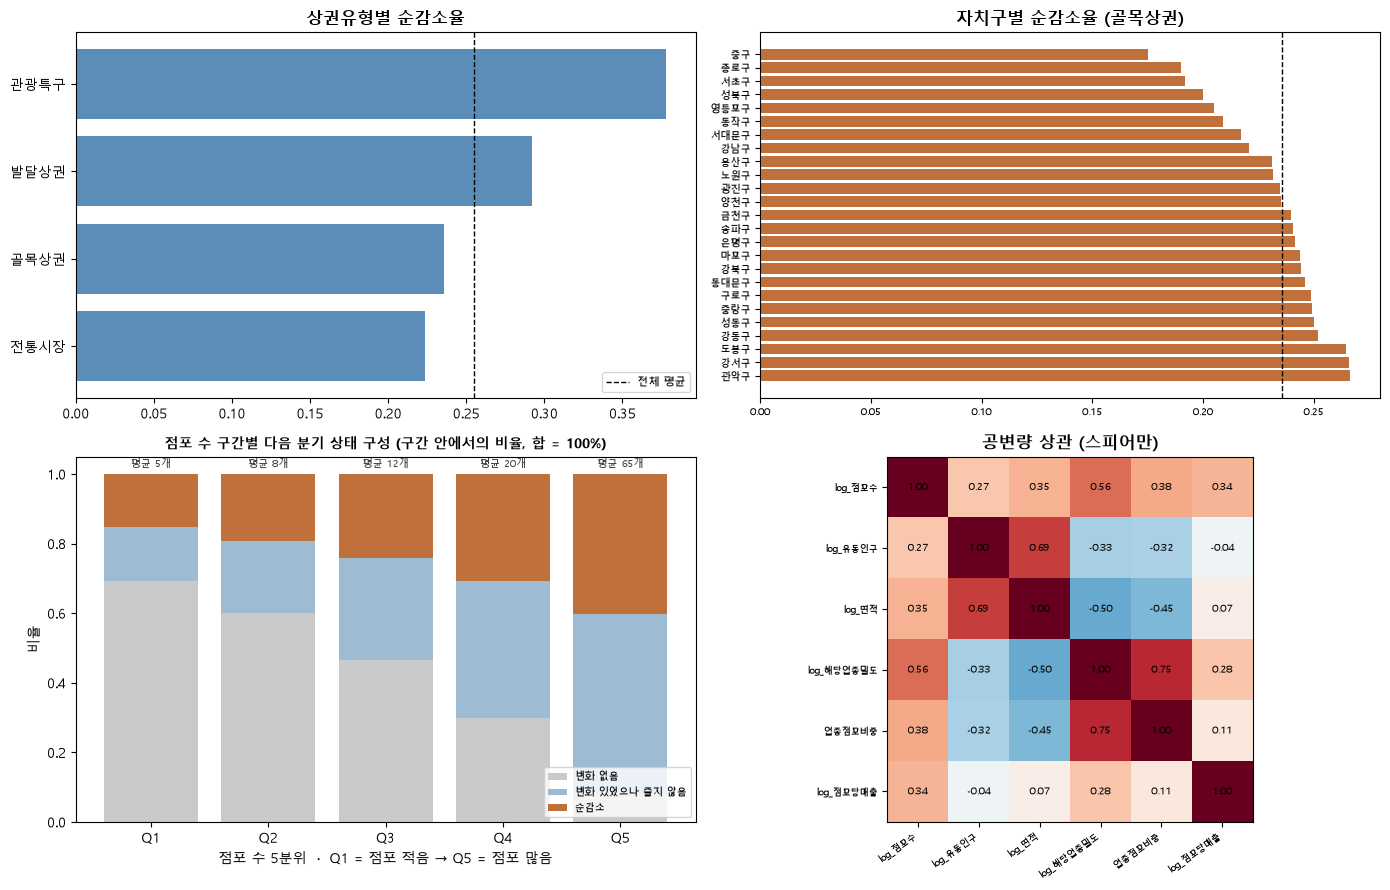

상관이 큰 쌍 (스피어만)
  log_해당업종밀도       ~ 업종점포비중           +0.753
  log_유동인구         ~ log_면적           +0.692
  log_점포수          ~ log_해당업종밀도       +0.558
  log_면적           ~ log_해당업종밀도       -0.503

|r| > 0.8 인 쌍 0개

※ 0.6이라는 눈금에 규칙은 없음. 그리고 트리 계열 모형에서 상관은 «예측»을 망치지 않음.
  망치는 것은 «해석»임 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져서
  각각의 중요도가 실제보다 낮게 보임. 다음 노트북에서 SHAP 순위를 읽을 때
  위 상위 쌍은 하나의 덩어리로 보아야 함.


In [18]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
ax[0,0].barh(t_type.index, t_type["순감소율"], color="#5b8db8")
ax[0,0].axvline(d["y"].mean(), ls="--", c="k", lw=1, label="전체 평균")
ax[0,0].set_title("상권유형별 순감소율", weight="bold"); ax[0,0].legend(fontsize=8)

ax[0,1].barh(t_gu.index, t_gu["순감소율"], color="#c0703a")
ax[0,1].axvline(gm["y"].mean(), ls="--", c="k", lw=1)
ax[0,1].set_title(f"자치구별 순감소율 ({TARGET_TYPE})", weight="bold"); ax[0,1].tick_params(labelsize=7)

st = d.groupby(["규모구간", "다음상태"], observed=True).size().unstack(fill_value=0)
st = st.div(st.sum(axis=1), axis=0)[[S_NONE, S_FLAT, S_DROP]]
bot = np.zeros(len(st))
for c, col in zip(st.columns, ["#c9c9c9", "#9dbcd4", "#c0703a"]):
    ax[1,0].bar([f"Q{i+1}" for i in st.index], st[c], bottom=bot, color=col, label=c)
    bot += st[c].values
ax[1,0].set_title("점포 수 구간별 다음 분기 상태 구성 (구간 안에서의 비율, 합 = 100%)",
                  weight="bold", fontsize=10)
ax[1,0].set_xlabel("점포 수 5분위  ·  Q1 = 점포 적음 → Q5 = 점포 많음")
for xi, (qi, row) in enumerate(st.iterrows()):
    ax[1,0].text(xi, 1.02, f"평균 {size_tab['평균점포'].iloc[xi]:.0f}개",
                 ha="center", fontsize=7.5, color="#444")
ax[1,0].legend(fontsize=7, loc="lower right"); ax[1,0].set_ylabel("비율")

cov = ["log_점포수", "log_유동인구", "log_면적", "log_해당업종밀도", "업종점포비중",
       "log_점포당매출"]
corr = d[cov].corr(method="spearman")
im = ax[1,1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1,1].set_xticks(range(len(cov))); ax[1,1].set_xticklabels(cov, rotation=35, fontsize=6.5, ha="right")
ax[1,1].set_yticks(range(len(cov))); ax[1,1].set_yticklabels(cov, fontsize=6.5)
for i in range(len(cov)):
    for j in range(len(cov)):
        ax[1,1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax[1,1].set_title("공변량 상관 (스피어만)", weight="bold")
plt.tight_layout(); plt.savefig(FIG / "basic_eda.png", dpi=130); plt.show()
pairs = [(cov[a], cov[b], corr.iloc[a, b]) for a in range(len(cov)) for b in range(a+1, len(cov))]
pairs.sort(key=lambda t: -abs(t[2]))
print("상관이 큰 쌍 (스피어만)")
for a_, b_, v_ in pairs[:4]:
    print(f"  {a_:16} ~ {b_:16} {v_:+.3f}")
print(f"\n|r| > 0.8 인 쌍 {sum(1 for _,_,v_ in pairs if abs(v_) > 0.8)}개")
print("\n※ 0.6이라는 눈금에 규칙은 없음. 그리고 트리 계열 모형에서 상관은 «예측»을 망치지 않음.")
print("  망치는 것은 «해석»임 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져서")
print("  각각의 중요도가 실제보다 낮게 보임. 다음 노트북에서 SHAP 순위를 읽을 때")
print("  위 상위 쌍은 하나의 덩어리로 보아야 함.")

---
# 5. 기준선과 가설 검토

모델을 만들기 전에 **아무것도 안 하는 규칙이 얼마나 맞히는지** 먼저 재 둠.
이 값을 넘지 못하면 모델을 쓸 이유가 없음.

## 5-1. 기준선 네 가지

| 기준선 | 규칙 |
|---|---|
| 무작위 | 전체 양성률(기저율) |
| 직전 분기 | 직전 분기에 순감소였으면 위험으로 찍음 |
| 상권변화지표 | 서울시 공식 지표가 `HL 상권축소`이면 위험으로 찍음 |
| **점포 수** | 점포 수가 많은 칸부터 차례로 위험으로 찍음 |

**«점포 수» 를 반드시 넣어야 하는 이유** — 3-1에서 본 것처럼 큰 칸일수록 사건이 자주 일어나고
그만큼 순감소로 잡힐 확률도 높음. 즉 **점포 수 하나만 알아도 어느 정도는 맞힘.**
이 기준선을 세워 두지 않으면 모델의 성능이 «위험을 읽어낸 것» 인지
«그냥 큰 칸을 고른 것» 인지 구분할 수 없음.

공정한 비교를 위해 점포 수 기준선이 위험으로 찍는 개수를 **직전 분기 기준선과 같게** 맞춤.
`Lift = 정밀도 ÷ 기저율` 이며, 1.0이면 무작위와 같음. (Lift 1.5 = 아무렇게나 찍을 때보다 1.5배 잘 맞힘)


In [19]:
def evaluate(y_true, pred, name):
    y_true = np.asarray(y_true); pred = np.asarray(pred)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    base = y_true.mean()
    prec = tp / (tp + fp) if tp + fp else np.nan
    rec  = tp / (tp + fn) if tp + fn else np.nan
    return {"기준선": name, "위험으로 찍은 수": tp + fp, "정밀도": prec, "재현율": rec,
            "Lift": prec / base if base else np.nan}

b = d[d["상권_변화_지표"].notna()].copy()
k = int(b["순감소_현재"].sum())                      # 직전 분기 기준선이 찍은 개수와 같게 맞춤
규모예측 = np.zeros(len(b), dtype=int)
규모예측[np.argsort(-b["전체_점포_수"].values, kind="stable")[:k]] = 1
b["점포수만"] = 규모예측

rows = [evaluate(b["y"], np.ones(len(b)), "무작위(전부 위험)"),
        evaluate(b["y"], b["순감소_현재"], "직전 분기"),
        evaluate(b["y"], b["기준선_위험"], "상권변화지표(HL)"),
        evaluate(b["y"], b["점포수만"],    f"점포 수(상위 {k:,}칸)")]
bl = pd.DataFrame(rows)
bl[["정밀도", "재현율", "Lift"]] = bl[["정밀도", "재현율", "Lift"]].round(3)
display(bl)
print(f"기저율 = {b['y'].mean():.1%}  <- 모델은 이 표의 Lift를 넘어야 의미가 있음")

,기준선,위험으로 찍은 수,정밀도,재현율,Lift
0,무작위(전부 위험),67475,0.255,1.000,1.000
1,직전 분기,15682,0.284,0.259,1.115
2,상권변화지표(HL),12608,0.244,0.179,0.956
3,"점포 수(상위 15,682칸)",15682,0.394,0.359,1.545


기저율 = 25.5%  <- 모델은 이 표의 Lift를 넘어야 의미가 있음


In [20]:
ct2 = pd.crosstab(b["순감소_현재"], b["y"])
chi2, p, dof, _ = chi2_contingency(ct2, correction=False)
V = np.sqrt(chi2 / ct2.values.sum())
OR = (ct2.iloc[1,1] * ct2.iloc[0,0]) / (ct2.iloc[1,0] * ct2.iloc[0,1])
display(ct2)
print(f"chi2({dof}) = {chi2:.1f}, p = {p:.3g}, Cramer V = {V:.3f}, 오즈비 = {OR:.2f}")
print("-> p는 사실상 0이지만 V가 작으면 직전 분기만으로는 예측력이 약하다는 뜻임. "
      "p-value만 보고 결론을 내면 안 되는 이유의 실물임.")

y,0,1
순감소_현재,,
0,39057,12736
1,11228,4454


chi2(1) = 92.1, p = 8.15e-22, Cramer V = 0.037, 오즈비 = 1.22
-> p는 사실상 0이지만 V가 작으면 직전 분기만으로는 예측력이 약하다는 뜻임. p-value만 보고 결론을 내면 안 되는 이유의 실물임.


## 5-2. 층화 평가 — 점포 수를 고정하면 무엇이 남는가

전체 표본에서 잰 Lift는 «규모가 큰 칸을 골라낸 몫» 을 포함함.
그래서 **점포 수 5분위 안에서 다시** 같은 기준선을 재 봄.
층 안에서는 칸의 크기가 서로 비슷하므로, 여기서도 Lift가 1을 넘으면
그 기준선은 **규모가 아닌 무언가를 읽고 있다**고 말할 수 있음.

이 표는 다음 노트북에서 모델을 평가할 때도 같은 방식으로 다시 만들어,
모델이 규모 이상의 정보를 쓰는지 확인하는 데 사용함.


In [21]:
rows = []
for q_, s in b.groupby("규모구간"):
    base = s["y"].mean()
    kk = int(s["순감소_현재"].sum())
    pred_size = np.zeros(len(s), dtype=int)
    pred_size[np.argsort(-s["전체_점포_수"].values, kind="stable")[:kk]] = 1
    r = {"규모구간": f"Q{int(q_)+1}", "칸수": len(s),
         "평균점포": round(s["전체_점포_수"].mean(), 1), "기저율": round(base, 3)}
    for nm, pred in [("직전 분기", s["순감소_현재"].values), ("상권변화지표", s["기준선_위험"].values),
                     ("점포 수", pred_size)]:
        tp = int(((pred == 1) & (s["y"].values == 1)).sum()); n1 = int(pred.sum())
        r[f"{nm} Lift"] = round((tp / n1) / base, 3) if n1 and base else np.nan
    rows.append(r)
strat = pd.DataFrame(rows).set_index("규모구간")
display(strat)
print("-> «점포 수» 의 층내 Lift가 1 근처로 내려가면, 전체 표본에서의 성능이")
print("   상권의 위험을 읽은 것이 아니라 규모를 고른 결과였다는 뜻임.")

,칸수,평균점포,기저율,직전 분기 Lift,상권변화지표 Lift,점포 수 Lift
규모구간,,,,,,
Q1,15520,5.4,0.151,0.947,1.014,1.131
Q2,14018,7.9,0.193,0.963,1.054,1.151
Q3,12139,11.7,0.243,1.000,1.009,1.094
Q4,12718,19.6,0.308,0.955,1.056,1.096
Q5,13080,65.5,0.403,1.013,0.969,1.064


-> «점포 수» 의 층내 Lift가 1 근처로 내려가면, 전체 표본에서의 성능이
   상권의 위험을 읽은 것이 아니라 규모를 고른 결과였다는 뜻임.


## 5-3. 업종별 순감소율과 규모 교란

처리군은 **선험적 근거로 미리 고정함.** 순감소율이 가장 높은 업종을 고른 다음 그 격차를 검정하면
선택 효과가 섞여 들어가기 때문임. 표본이 가장 크고 골목상권을 대표하는 **한식음식점**으로 정함.

In [22]:
gm = d[d["상권유형"] == TARGET_TYPE].copy()
t_ind = (gm.groupby("서비스_업종_코드_명")
         .agg(순감소율=("y", "mean"), 칸수=("y", "size"),
              평균점포=("전체_점포_수", "mean"), 중앙유동인구=("총_유동인구_수", "median"))
         .sort_values("순감소율", ascending=False))
display(t_ind.round(3))

TREAT = "한식음식점"          # 선험적 고정 (표본 최대 · 대표 업종)
gm["처리"] = (gm["서비스_업종_코드_명"] == TREAT).astype(int)
p1 = gm.loc[gm["처리"] == 1, "y"].mean(); p0 = gm.loc[gm["처리"] == 0, "y"].mean()
print(f"\n처리군 {TREAT} n={int(gm['처리'].sum()):,} 순감소율 {p1:.1%}")
print(f"대조군 기타 외식  n={int((1-gm['처리']).sum()):,} 순감소율 {p0:.1%}")
print(f"단순 격차 {p1-p0:+.1%}p")

,순감소율,칸수,평균점포,중앙유동인구
서비스_업종_코드_명,,,,
한식음식점,0.253,9957,21.315,779241.0
커피-음료,0.244,7741,12.595,893978.0
호프-간이주점,0.239,4596,11.783,1170658.0
패스트푸드점,0.237,1440,7.090,1515928.5
양식음식점,0.228,1478,11.118,1305611.5
분식전문점,0.222,3634,8.234,1264523.0
일식음식점,0.216,1036,8.420,1549588.5
제과점,0.206,1636,7.411,1319055.5
치킨전문점,0.201,1922,6.703,1391462.5



처리군 한식음식점 n=9,957 순감소율 25.3%
대조군 기타 외식  n=24,690 순감소율 22.9%
단순 격차 +2.4%p


In [23]:
r = np.corrcoef(t_ind["평균점포"], t_ind["순감소율"])[0, 1]
print(f"업종 평균점포수 <-> 순감소율 상관 r = {r:.3f}")
print("r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 큼\n")

piv = gm.pivot_table(index="규모구간", columns="처리", values="y",
                     aggfunc=["mean", "size"], observed=True)
tbl = pd.DataFrame({"대조군_순감소율": piv[("mean", 0)], "처리군_순감소율": piv[("mean", 1)],
                    "대조n": piv[("size", 0)].astype("Int64"), "처리n": piv[("size", 1)].astype("Int64")})
tbl["격차"] = tbl["처리군_순감소율"] - tbl["대조군_순감소율"]
tbl.index = [f"Q{int(i)+1}" for i in tbl.index]
display(tbl.round(3))
print("※ 규모 구간을 고정했을 때 격차가 줄거나 부호가 뒤집히면, 단순 격차는 규모 교란의 산물임")

업종 평균점포수 <-> 순감소율 상관 r = 0.657
r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 큼



,대조군_순감소율,처리군_순감소율,대조n,처리n,격차
Q1,0.163,0.118,9147,1107,-0.044
Q2,0.211,0.150,6914,1604,-0.061
Q3,0.269,0.208,4766,1833,-0.061
Q4,0.343,0.294,2827,2840,-0.048
Q5,0.435,0.360,1036,2573,-0.075


※ 규모 구간을 고정했을 때 격차가 줄거나 부호가 뒤집히면, 단순 격차는 규모 교란의 산물임


### 처리군을 미리 고정해야 하는 이유 — 순열검정으로 확인

「순감소율이 가장 높은 업종을 고른 뒤 그 격차를 검정한다」가 왜 안 되는지를 수치로 보임.

**업종 사이에 진짜 차이가 0이라고 가정**하고 `y`를 무작위로 섞어 같은 계산을 2,000번 반복함.
차이가 없는데도 «10개 중 최고»는 전체 평균보다 높게 나옴 — 10번 뽑아 최대를 고르는 행위 자체가
**위쪽 꼬리를 뽑기** 때문임. 표집 오차의 운이 좋았던 업종이 1위가 됨.

그래서 최고를 고른 뒤 그 격차를 검정하면 **이미 부풀려진 값을 검정**하는 것이고,
p-value가 실제보다 작게(더 유의하게) 나옴. 같은 데이터로 «고르기»와 «검정»을 둘 다 해서 생기는 문제임.


In [24]:
rng = np.random.default_rng(0)
ind = gm["서비스_업종_코드_명"].values; yv = gm["y"].values
obs = gm.groupby("서비스_업종_코드_명")["y"].mean()
gap_obs = obs.max() - obs.min()

gaps, maxs = [], []
for _ in range(2000):
    m_ = pd.Series(rng.permutation(yv)).groupby(ind).mean()
    gaps.append(m_.max() - m_.min()); maxs.append(m_.max())
gaps = np.array(gaps); maxs = np.array(maxs)

print(f"관측  최고({obs.idxmax()}) {obs.max():.3f} − 최저({obs.idxmin()}) {obs.min():.3f} = 격차 {gap_obs:.4f}")
print(f"\n업종 간 차이가 0이라고 가정하고 2,000번 섞으면")
print(f"  최고−최저 격차     평균 {gaps.mean():.4f} · 95분위 {np.quantile(gaps,.95):.4f} · 최대 {gaps.max():.4f}")
print(f"  «최고» 업종 순감소율 평균 {maxs.mean():.4f}  (전체 평균 {yv.mean():.4f})")
print(f"  → 아무 차이가 없어도 «최고»는 전체 평균보다 {maxs.mean()-yv.mean():+.4f} 높게 나옴")
print(f"     이 {maxs.mean()-yv.mean():+.4f} 가 «선택 효과»의 크기임\n")
p_perm = (gaps >= gap_obs).mean()
print(f"순열 p-value = {p_perm:.4f}  →  " +
      ("업종 간 차이는 우연으로 설명되지 않음" if p_perm < .05 else "우연 범위 안"))
print("단, 이것은 «차이가 있는가»에 대한 사후 확인임.")
print("처리군을 무엇으로 할지는 이 결과를 보기 전에 정해야 하므로 한식음식점을 선험적으로 고정함.")

관측  최고(한식음식점) 0.253 − 최저(중식음식점) 0.191 = 격차 0.0613

업종 간 차이가 0이라고 가정하고 2,000번 섞으면
  최고−최저 격차     평균 0.0297 · 95분위 0.0456 · 최대 0.0658
  «최고» 업종 순감소율 평균 0.2506  (전체 평균 0.2357)
  → 아무 차이가 없어도 «최고»는 전체 평균보다 +0.0149 높게 나옴
     이 +0.0149 가 «선택 효과»의 크기임

순열 p-value = 0.0010  →  업종 간 차이는 우연으로 설명되지 않음
단, 이것은 «차이가 있는가»에 대한 사후 확인임.
처리군을 무엇으로 할지는 이 결과를 보기 전에 정해야 하므로 한식음식점을 선험적으로 고정함.


## 5-4. 공변량 균형 (SMD)

|SMD| < 0.1 균형 / 0.1~0.25 불균형 / 0.25 초과 심각.
두 집단을 비교하려면 **비교 전에 조건이 맞아 있는지** 부터 확인해야 함.

In [25]:
COVARIATES = ["log_점포수", "log_유동인구", "log_면적", "log_해당업종밀도",
              "log_점포당매출", "업종점포비중"]
def smd(a, b_):
    return (a.mean() - b_.mean()) / np.sqrt((a.var() + b_.var()) / 2)

rows = []
for c in COVARIATES:
    a = gm.loc[gm["처리"] == 1, c].dropna(); b_ = gm.loc[gm["처리"] == 0, c].dropna()
    s = smd(a, b_)
    rows.append({"공변량": c, "처리군평균": a.mean(), "대조군평균": b_.mean(), "SMD": s,
                 "판정": "균형" if abs(s) < .1 else ("불균형" if abs(s) < .25 else "심각한 불균형")})
smd_tbl = pd.DataFrame(rows)
smd_tbl[["처리군평균", "대조군평균", "SMD"]] = smd_tbl[["처리군평균", "대조군평균", "SMD"]].round(3)
display(smd_tbl)

,공변량,처리군평균,대조군평균,SMD,판정
0,log_점포수,2.790,2.158,0.999,심각한 불균형
1,log_유동인구,13.410,13.824,-0.447,심각한 불균형
2,log_면적,11.345,11.653,-0.473,심각한 불균형
3,log_해당업종밀도,1.121,0.619,1.305,심각한 불균형
4,log_점포당매출,17.457,16.265,1.128,심각한 불균형
5,업종점포비중,0.113,0.043,1.557,심각한 불균형


---
# 6. 후보 변수 판별력 점검

새로 넣은 세 변수가 **다음 노트북의 피처로 쓸 값을 하는지** 여기서 미리 재 둠.
넣어 보고 안 되면 빼는 것이 판단 근거로 남으므로, 결과가 나쁘더라도 기록함.

**통과해야 하는 조건이 둘임.**

1. **분기 안에서 변하는가** — 평가가 한 분기 안의 순위이므로, 분기 안에서 상수인 변수는
   무엇을 곱하거나 더해도 순위를 바꾸지 못함. 상수 `c`에 대해 `c × 값ᵢ` 는 `값ᵢ` 의 단조 변환이라
   줄 세운 결과가 같음.
2. **규모와 다른 축인가** — 이미 `점포 수`가 가장 센 신호이므로, 규모와 상관이 높으면
   새 정보가 아니라 규모를 우회적으로 다시 넣는 것임.


In [26]:
from sklearn.metrics import roc_auc_score

CAND = ["운영_영업_개월_평균", "운영개월_서울대비", "외식물가지수", "외식지출전망"]
REF  = ["log_점포수", "log_유동인구"]

rows = []
for c_ in CAND + REF:
    v = d[[c_, "y"]].dropna()
    auc = roc_auc_score(v["y"], v[c_])
    nq  = d.groupby("기준_년분기_코드")[c_].nunique()
    rows.append({"변수": c_,
                 "분기내 고유값": f"{nq.min()}~{nq.max()}",
                 "분기내 변동": "있음" if nq.min() > 1 else "없음(상수)",
                 "AUC": auc, "|AUC-0.5|": abs(auc - 0.5),
                 "규모상관": d[c_].corr(d["log_점포수"], method="spearman")})
cand_tab = pd.DataFrame(rows).set_index("변수")
display(cand_tab.round(3))

print("판정")
for c_, r_ in cand_tab.iterrows():
    if c_ in REF: continue
    if r_["분기내 변동"] != "있음":
        print(f"  {c_:20} 탈락 — 분기 안에서 상수라 순위에 기여할 수 없음")
    elif r_["|AUC-0.5|"] < 0.02:
        print(f"  {c_:20} 탈락 — 판별력 없음 (AUC {r_['AUC']:.3f})")
    else:
        print(f"  {c_:20} 통과 — 약하지만 방향이 있고(AUC {r_['AUC']:.3f}) "
              f"규모와 다른 축(상관 {r_['규모상관']:+.2f})")

,분기내 고유값,분기내 변동,AUC,|AUC-0.5|,규모상관
변수,,,,,
운영_영업_개월_평균,126~133,있음,0.473,0.027,-0.092
운영개월_서울대비,126~133,있음,0.468,0.032,-0.099
외식물가지수,1~1,없음(상수),0.514,0.014,0.003
외식지출전망,1~1,없음(상수),0.499,0.001,-0.003
log_점포수,188~198,있음,0.637,0.137,1.000
log_유동인구,1355~1378,있음,0.556,0.056,0.273


판정
  운영_영업_개월_평균          통과 — 약하지만 방향이 있고(AUC 0.473) 규모와 다른 축(상관 -0.09)
  운영개월_서울대비            통과 — 약하지만 방향이 있고(AUC 0.468) 규모와 다른 축(상관 -0.10)
  외식물가지수               탈락 — 분기 안에서 상수라 순위에 기여할 수 없음
  외식지출전망               탈락 — 분기 안에서 상수라 순위에 기여할 수 없음


In [27]:
# 통과한 변수의 5분위별 순감소율 — 단조성 확인
for c_ in ["운영_영업_개월_평균"]:
    t_ = (d.assign(_q=pd.qcut(d[c_], 5, labels=False, duplicates="drop"))
          .groupby("_q").agg(칸수=("y", "size"), 평균값=(c_, "mean"),
                             평균점포=("전체_점포_수", "mean"), 순감소율=("y", "mean")))
    t_.index = [f"Q{i_+1}" for i_ in t_.index]
    print(f"[{c_}]")
    display(t_.round(3))
    mono = t_["순감소율"].is_monotonic_increasing or t_["순감소율"].is_monotonic_decreasing
    print(f"  단조 {'예' if mono else '아니오'} · 격차 {t_['순감소율'].max()-t_['순감소율'].min():.3f}"
          f" · 구간 간 평균점포 {t_['평균점포'].min():.1f}~{t_['평균점포'].max():.1f}")
    print("  → 평균점포가 구간에 따라 크게 변하지 않으면 규모 교란이 아니라는 뜻임\n")

print("경제지표는 분기 안에서 상수이므로 5분위를 나누면 «분기를 나눈 것»과 같아져 의미가 없음.")
print("아래에서 그것을 직접 확인함.")

[운영_영업_개월_평균]


,칸수,평균값,평균점포,순감소율
Q1,14170,82.521,26.469,0.278
Q2,14210,97.225,22.683,0.266
Q3,13374,105.420,19.642,0.252
Q4,12967,114.450,17.763,0.247
Q5,12754,136.587,19.726,0.228


  단조 예 · 격차 0.050 · 구간 간 평균점포 17.8~26.5
  → 평균점포가 구간에 따라 크게 변하지 않으면 규모 교란이 아니라는 뜻임

경제지표는 분기 안에서 상수이므로 5분위를 나누면 «분기를 나눈 것»과 같아져 의미가 없음.
아래에서 그것을 직접 확인함.


In [28]:
# 경제지표가 상수라는 것의 의미 — 한 분기를 떼어 직접 확인
one_q = d[d["기준_년분기_코드"] == 20254]
print(f"2025Q4 {len(one_q):,}칸에서 각 변수가 갖는 서로 다른 값의 개수")
for c_ in ["외식물가지수", "외식지출전망", "운영_영업_개월_평균", "전체_점포_수"]:
    print(f"  {c_:20} {one_q[c_].nunique():>6}개")
print()
print("외식물가지수·외식지출전망은 5,479칸 전부가 같은 값 하나임.")
print("이 열로는 어떤 칸이 더 위험한지 구분할 수 없음 — 정렬해도 순서가 바뀌지 않기 때문임.")
print("상권 단위 변수와 곱해도 마찬가지임: 상수를 곱하는 것은 단조 변환이라 순위가 보존됨.")
print("\n분기를 가로지르면 «물가가 높은 분기에는 개업이 적은 것이 더 위험하다» 같은")
print("교호작용이 있을 수 있고, 그것은 트리 모형이 두 변수를 모두 가지면 스스로 잡음.")
print("다만 분기가 12개뿐이고 테스트가 1개 분기이므로, 테스트 분기 안의 순위는 여전히 바뀌지 않음.")

2025Q4 5,479칸에서 각 변수가 갖는 서로 다른 값의 개수
  외식물가지수                    1개
  외식지출전망                    1개
  운영_영업_개월_평균             132개
  전체_점포_수                 188개

외식물가지수·외식지출전망은 5,479칸 전부가 같은 값 하나임.
이 열로는 어떤 칸이 더 위험한지 구분할 수 없음 — 정렬해도 순서가 바뀌지 않기 때문임.
상권 단위 변수와 곱해도 마찬가지임: 상수를 곱하는 것은 단조 변환이라 순위가 보존됨.

분기를 가로지르면 «물가가 높은 분기에는 개업이 적은 것이 더 위험하다» 같은
교호작용이 있을 수 있고, 그것은 트리 모형이 두 변수를 모두 가지면 스스로 잡음.
다만 분기가 12개뿐이고 테스트가 1개 분기이므로, 테스트 분기 안의 순위는 여전히 바뀌지 않음.


---
# 7. 산출물

| 파일 | 내용 |
|---|---|
| `data/processed/02_merged.pkl` | 결합만 끝난 상태 (라벨 이전) |
| `data/processed/03_panel.pkl` | 라벨·파생변수까지 완료된 분석 패널 |
| `data/processed/04_model_input.csv` | 다음 노트북이 바로 읽는 모델 입력 |
| `figures/*.png` | 탐색 그림 |

다음 노트북에서 할 일을 여기서 고정해 둠.

1. **시간순 분할** — 학습 2023Q1~2025Q2 / 검증 2025Q3 / 테스트 2025Q4.
   각 분기는 그 다음 분기의 결과로 채점함. 테스트 분기는 마지막에 한 번만 사용
2. **기준선 통과 확인** — 5-1의 네 기준선과 5-2의 구간별 값을 모델에 그대로 다시 적용
3. **집객시설 정리** — 지금 남긴 항목 전부를 넣고 학습한 뒤, 기여도와 규모 상관을 함께 보고 추림
4. **후보 변수 재확인** — 6장에서 통과·탈락한 변수를 모델에서 다시 확인
5. **2단계 모형 비교** — `P(사건) × P(순감소 | 사건)` 을 단일 모형과 같은 검증셋에서 비교
6. **위험도 예측과 지도 표출**


In [29]:
KEEP = (["기준_년분기_코드", "분기idx", "상권_코드", "상권_코드_명", "상권유형", "자치구",
         "행정동_코드", "행정동", "서비스_업종_코드", "서비스_업종_코드_명",
         "엑스좌표_값", "와이좌표_값", "영역_면적",
         "전체_점포_수", "일반_점포_수", "프랜차이즈_점포_수", "개업_점포_수", "폐업_점포_수",
         "상권_전체점포", "총_유동인구_수", "당월_매출_금액", "당월_매출_건수",
         "역세권", "상권_변화_지표", "기준선_위험",
         "운영_영업_개월_평균", "운영개월_서울대비", "외식물가지수", "외식지출전망",
         "업종점포비중", "해당업종_점포밀도", "요식업_점포밀도", "프랜차이즈비율", "점포당매출", "매출결측",
         "log_점포수", "log_유동인구", "log_면적", "log_해당업종밀도", "log_요식업밀도", "log_점포당매출",
         "순감소_현재", "사건_현재", "규모구간", "다음상태", "사건_다음", "y"]
        + FAC_KEEP + [c for c in d.columns if c.startswith("밀도_")])
KEEP = [c for c in dict.fromkeys(KEEP) if c in d.columns]
out = d[KEEP].copy()
out.to_csv(PROC / "04_model_input.csv", index=False, encoding="utf-8-sig")
print(f"[저장] 04_model_input.csv  {out.shape}")
print(f"  분기 {out['기준_년분기_코드'].nunique()}개 · 상권 {out['상권_코드'].nunique():,}개 "
      f"· 업종 {out['서비스_업종_코드_명'].nunique()}개")
print(f"  양성률 {out['y'].mean():.1%} · 집객시설 항목 {len(FAC_KEEP)}개 · 후보 변수 4개")
print("\n컬럼 목록")
print("  " + ", ".join(KEEP))

[저장] 04_model_input.csv  (67475, 71)
  분기 12개 · 상권 1,422개 · 업종 10개
  양성률 25.5% · 집객시설 항목 12개 · 후보 변수 4개

컬럼 목록
  기준_년분기_코드, 분기idx, 상권_코드, 상권_코드_명, 상권유형, 자치구, 행정동_코드, 행정동, 서비스_업종_코드, 서비스_업종_코드_명, 엑스좌표_값, 와이좌표_값, 영역_면적, 전체_점포_수, 일반_점포_수, 프랜차이즈_점포_수, 개업_점포_수, 폐업_점포_수, 상권_전체점포, 총_유동인구_수, 당월_매출_금액, 당월_매출_건수, 역세권, 상권_변화_지표, 기준선_위험, 운영_영업_개월_평균, 운영개월_서울대비, 외식물가지수, 외식지출전망, 업종점포비중, 해당업종_점포밀도, 요식업_점포밀도, 프랜차이즈비율, 점포당매출, 매출결측, log_점포수, log_유동인구, log_면적, log_해당업종밀도, log_요식업밀도, log_점포당매출, 순감소_현재, 사건_현재, 규모구간, 다음상태, 사건_다음, y, 버스_정거장_수, 약국_수, 관공서_수, 은행_수, 지하철_역_수, 유치원_수, 숙박_시설_수, 일반_병원_수, 슈퍼마켓_수, 극장_수, 대학교_수, 종합병원_수, 밀도_버스_정거장, 밀도_약국, 밀도_관공서, 밀도_은행, 밀도_지하철_역, 밀도_유치원, 밀도_숙박_시설, 밀도_일반_병원, 밀도_슈퍼마켓, 밀도_극장, 밀도_대학교, 밀도_종합병원


---
## 정리

- 요식업 10종 · 골목상권 중심의 **상권 × 업종 × 분기** 패널을 만들고, 다음 분기 순감소 라벨을 붙임.
- `y=0`이 **「변화 없음」**과 **「변화 있었으나 줄지 않음」**의 합이라는 점을 분해해 보였고,
  **상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높다**는 것을 규모 구간별로 측정해 남김.
  미래 사건 여부로는 표본을 고를 수 없으므로 이 칸들을 **버리지 않고** 유지함.
- 규모를 **밀도 · 면적 · 비중** 세 축으로 나누어 담아, 어느 축이 위험을 만드는지 구분할 수 있게 함.
- 기준선에 **«점포 수»** 를 포함시키고 **층화 Lift**를 함께 재, 다음 노트북의 모델이
  «규모를 고른 것» 인지 «위험을 읽은 것» 인지 판정할 수 있는 기준을 만들어 둠.
- **전국 단위 경제지표는 쓰지 않음.** 한 분기 안에서 모든 상권이 같은 값이 되어
  상권 사이의 순위를 바꾸지 못하므로, 이 과제의 평가 방식에서는 기여할 수 없음.
